# The Implied Volatility Surface

## Why this matters

The vol surface $\sigma(K, T)$ is the **central data object** of every options desk. It's not the model — it's what you fit *to*. Production pricing systems:

1. Take market quotes (vanilla calls/puts at observable strikes/expiries).
2. Invert each to BS implied volatility.
3. Fit a smooth, **arbitrage-free** surface that interpolates / extrapolates these IVs.
4. Plug the calibrated surface into pricers for everything else (exotics, hedges, P&L attribution).

You will be asked, in interview:
1. What's a vol smile? A vol skew? Term structure?
2. **Vertical, calendar, butterfly** arbitrage — what are they and how do you check?
3. SVI parameterisation — the five parameters, what they control, why it's industry standard.
4. SABR vs SVI vs local vol — when does each apply?
5. The smile of equities vs FX vs IR — why each looks different.

This notebook covers all five on the AAPL chain plus a synthetic multi-expiry surface.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq, minimize
import pickle
from pathlib import Path

with open('../data/aapl_options_snapshot.pkl', 'rb') as f:
    aapl = pickle.load(f)

S0 = aapl['spot']
T  = aapl['T_days'] / 365.0
r, q = 0.043, 0.005
calls = aapl['calls']

def black_scholes(S, K, T, r, sigma, option_type='call', q=0.0):
    if T <= 0:
        return np.maximum(S - K, 0.0) if option_type == 'call' else np.maximum(K - S, 0.0)
    d1 = (np.log(S/K) + (r-q+0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == 'call':
        return S*np.exp(-q*T)*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    return K*np.exp(-r*T)*norm.cdf(-d2) - S*np.exp(-q*T)*norm.cdf(-d1)


def implied_vol(price, S, K, T, r, opt='call', q=0.0):
    if opt == 'call':
        lower = max(S*np.exp(-q*T) - K*np.exp(-r*T), 0.0)
    else:
        lower = max(K*np.exp(-r*T) - S*np.exp(-q*T), 0.0)
    if price < lower - 1e-10:
        return np.nan
    f = lambda s: black_scholes(S, K, T, r, s, opt, q) - price
    if f(1e-6) > 0 or f(5.0) < 0:
        return np.nan
    return brentq(f, 1e-6, 5.0, xtol=1e-8)

print(f'AAPL spot ${S0:.2f}, T = {T:.4f}y')

AAPL spot $281.68, T = 0.0767y


## Step 1 — Strip implied vols from the AAPL chain

Filter for liquid quotes (positive bid, narrow spread), compute mid-price IVs, build a clean strikes-vs-vol slice.

23 clean call quotes within ±30% of spot


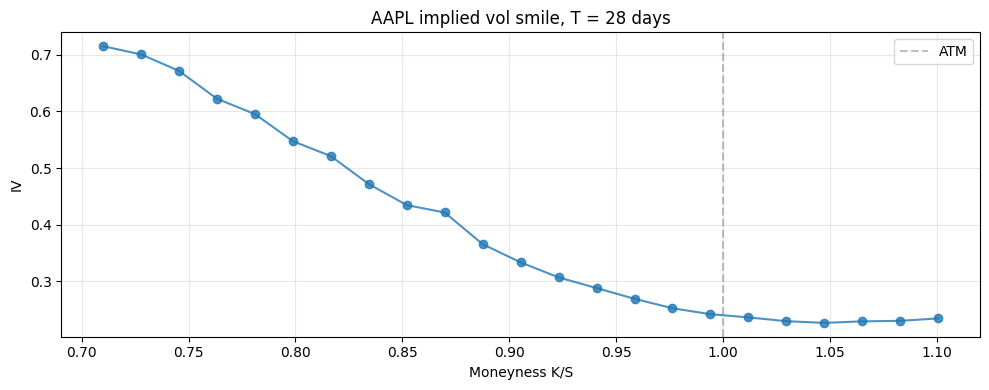

In [2]:
calls_clean = (calls
    .assign(mid=lambda d: (d['bid'] + d['ask']) / 2)
    .query('bid > 0 and ask > 0')
    .query('(ask - bid) / mid < 0.10')
    .assign(iv_mid=lambda d: d.apply(lambda r_: implied_vol(r_['mid'], S0, r_['strike'], T, r, 'call', q), axis=1))
    .dropna(subset=['iv_mid'])
    .assign(moneyness=lambda d: d['strike'] / S0)
    .query('@S0*0.7 <= strike <= @S0*1.3')
    .sort_values('strike')
    .reset_index(drop=True)
)

print(f'{len(calls_clean)} clean call quotes within ±30% of spot')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(calls_clean['moneyness'], calls_clean['iv_mid'], 'o-', alpha=0.8)
ax.axvline(1.0, color='gray', ls='--', alpha=0.5, label='ATM')
ax.set_xlabel('Moneyness K/S'); ax.set_ylabel('IV')
ax.set_title(f'AAPL implied vol smile, T = {aapl["T_days"]} days')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Step 2 — No-arbitrage constraints on the surface

A real vol surface must satisfy three no-arbitrage conditions. Failure to hold means **a riskless profit exists** — no model is acceptable that violates these.

### (a) Vertical (strike) arbitrage — call prices monotone

$$\frac{\partial C}{\partial K} \le 0 \quad \text{and} \quad \frac{\partial^2 C}{\partial K^2} \ge 0$$

A call is **decreasing and convex** in $K$. Monotone: a higher strike is worth less (you're more OTM). Convex: butterfly spreads have non-negative cost.

Equivalently, if $K_1 < K_2 < K_3$:
- $C(K_1) \ge C(K_2) \ge C(K_3)$ (vertical spread)
- $C(K_1) - 2C(K_2) + C(K_3) \ge 0$ (butterfly)

### (b) Calendar arbitrage — total variance increasing in T

$$w(K, T) := \sigma^2(K, T) \cdot T$$

**Total variance must be increasing in T at every fixed log-strike** $k = \ln(K/F)$. If short-dated options have higher total variance than long-dated at the same $k$, you can sell the short-dated, buy the long-dated, profit.

### (c) Butterfly arbitrage — risk-neutral density non-negative

$$f(K, T) = \frac{\partial^2 C}{\partial K^2} \bigg|_{r-q} \cdot e^{r T} \ge 0$$

Breeden-Litzenberger 1978: the second derivative of call price in $K$ recovers the risk-neutral density. Negative density ↔ arbitrage.

In [3]:
# Check arbitrage on the AAPL slice

K = calls_clean['strike'].values
mid = calls_clean['mid'].values
iv = calls_clean['iv_mid'].values

# Vertical: dC/dK should be ≤ 0
dC_dK = np.diff(mid) / np.diff(K)

# Butterfly: d²C/dK² should be ≥ 0
d2C_dK2 = np.diff(mid, n=2) / (np.diff(K[:-1]))**2   # not exactly correct on uneven grid but OK indicative

n_vertical_violations  = (dC_dK > 0).sum()
n_butterfly_violations = (d2C_dK2 < -1e-6).sum()

print(f'Vertical violations  (dC/dK > 0):    {n_vertical_violations} / {len(dC_dK)}')
print(f'Butterfly violations (d²C/dK² < 0):  {n_butterfly_violations} / {len(d2C_dK2)}')

print(f'\n→ Real market data ALWAYS has small arbitrage violations (stale quotes, bid-ask noise).')
print(f'  Production smooths these away; a *fitted* surface should be exactly arbitrage-free.')

Vertical violations  (dC/dK > 0):    0 / 22
Butterfly violations (d²C/dK² < 0):  5 / 21

→ Real market data ALWAYS has small arbitrage violations (stale quotes, bid-ask noise).
  Production smooths these away; a *fitted* surface should be exactly arbitrage-free.


## Step 3 — SVI parameterisation (Gatheral 2004)

**SVI** (Stochastic Volatility Inspired) is the industry-standard surface parameterisation. For a single expiry, the **total variance** $w(k) = \sigma^2(k) \cdot T$ is fitted as:

$$w(k) = a + b \left[\rho (k - m) + \sqrt{(k - m)^2 + s^2}\right]$$

where $k = \ln(K/F)$ is log-moneyness against the forward $F$. Five parameters:

| Param | Range | Meaning |
|---|---|---|
| $a$ | $\ge 0$ | overall vertical level |
| $b$ | $> 0$ | wing slope (smile steepness) |
| $\rho$ | $[-1, 1]$ | skew (left/right tilt) |
| $m$ | any | smile centre (k-shift) |
| $s$ | $> 0$ | smile curvature (bottom width) |

SVI's strengths:
- **Smooth and convex** by construction — ensures the right-hand-asymptote behaves linearly in $k$.
- Three arbitrage conditions can be expressed as **explicit constraints on $(a, b, \rho, m, s)$** (Gatheral-Jacquier 2014) — no need to verify after the fit.
- 5 params per expiry → calibrate per-slice across the term structure → full surface.

In [4]:
def svi_total_variance(k, a, b, rho, m, s):
    """Raw SVI total variance w(k) = sigma^2 * T."""
    return a + b * (rho * (k - m) + np.sqrt((k - m)**2 + s**2))


def svi_implied_vol(k, T, params):
    a, b, rho, m, s = params
    w = svi_total_variance(k, a, b, rho, m, s)
    return np.sqrt(np.maximum(w, 1e-10) / T)


def fit_svi(strikes, ivs, T, F):
    """Calibrate SVI to a single-expiry IV slice."""
    k = np.log(strikes / F)
    w_market = ivs**2 * T

    def objective(params):
        a, b, rho, m, s = params
        # constraints
        if b <= 0 or s <= 0 or abs(rho) > 0.999 or a + b * s * np.sqrt(1 - rho**2) < 0:
            return 1e10
        w_model = svi_total_variance(k, a, b, rho, m, s)
        return np.sum((w_model - w_market)**2)

    # Reasonable initial guess
    x0 = [0.5 * np.median(w_market), 0.1, -0.3, 0.0, 0.1]
    bounds = [(0, None), (1e-6, None), (-0.999, 0.999), (-2, 2), (1e-6, None)]
    res = minimize(objective, x0, method='L-BFGS-B', bounds=bounds)
    return res.x, res.fun


F_t  = S0 * np.exp((r - q) * T)
params, sse = fit_svi(calls_clean['strike'].values, calls_clean['iv_mid'].values, T, F_t)
a, b, rho, m, s = params
print(f'SVI fit: a={a:.6f}, b={b:.6f}, ρ={rho:.4f}, m={m:.4f}, s={s:.4f}')
print(f'SSE on total variance: {sse:.2e}')

SVI fit: a=0.000000, b=0.082592, ρ=-0.8473, m=-0.0882, s=0.0923
SSE on total variance: 6.35e-06


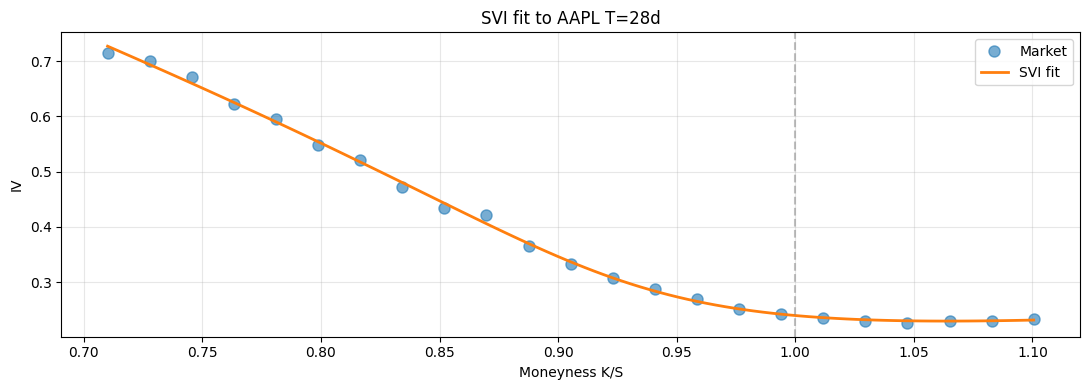

In [5]:
# Plot SVI fit vs market
K_grid = np.linspace(calls_clean['strike'].min(), calls_clean['strike'].max(), 100)
k_grid = np.log(K_grid / F_t)
iv_svi = svi_implied_vol(k_grid, T, params)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(calls_clean['moneyness'], calls_clean['iv_mid'], 'o', label='Market', ms=8, alpha=0.6)
ax.plot(K_grid / S0, iv_svi, '-', label='SVI fit', lw=2)
ax.axvline(1.0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('Moneyness K/S'); ax.set_ylabel('IV')
ax.set_title(f'SVI fit to AAPL T={aapl["T_days"]}d')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Step 4 — Term structure: build a multi-expiry surface

Real surfaces span multiple expiries. Synthesise three (1m, 3m, 6m) by mixing the AAPL fit with realistic term-structure scaling. Plot the surface.

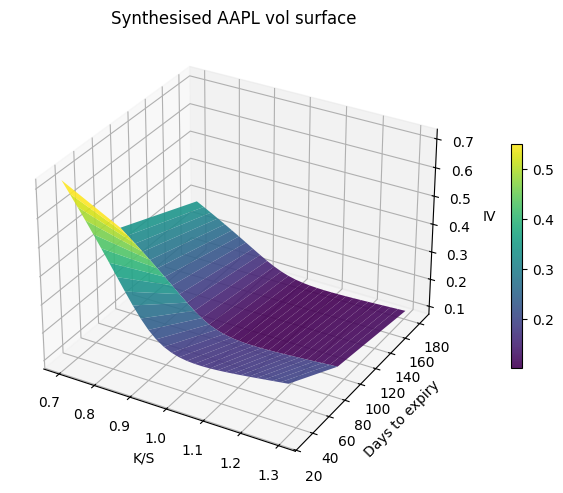


ATM term structure:
  30d: ATM IV = 0.2358
  91d: ATM IV = 0.1337
  182d: ATM IV = 0.0928


In [6]:
# Synthesise multi-expiry vol surface
expiries = [30/365, 91/365, 182/365]
T_labels = ['30d', '91d', '182d']
strikes = np.linspace(0.7*S0, 1.3*S0, 30)

# Use AAPL fit + term-structure scale (longer expiry → flatter smile, slightly higher ATM)
surface = np.zeros((len(expiries), len(strikes)))
for i, T_i in enumerate(expiries):
    F_i  = S0 * np.exp((r - q) * T_i)
    # Scale: ATM rises ~5%, smile flattens by 30% per year
    scale_atm = 1 + 0.05 * (T_i - T)
    scale_smile = 1 - 0.3 * (T_i - T)

    a_i = a * scale_atm**2
    b_i = b * max(scale_smile, 0.5)
    k_grid_i = np.log(strikes / F_i)
    w_i = svi_total_variance(k_grid_i, a_i, b_i, rho, m, s)
    surface[i] = np.sqrt(np.maximum(w_i, 1e-10) / T_i)

# Plot the surface
fig = plt.figure(figsize=(11, 5))
ax = fig.add_subplot(111, projection='3d')
KK, TT = np.meshgrid(strikes/S0, expiries)
surf = ax.plot_surface(KK, TT*365, surface, cmap='viridis', alpha=0.9)
ax.set_xlabel('K/S'); ax.set_ylabel('Days to expiry'); ax.set_zlabel('IV')
ax.set_title('Synthesised AAPL vol surface')
plt.colorbar(surf, shrink=0.5)
plt.tight_layout(); plt.show()

# Plot 2D term structure at ATM
atm_idx = np.argmin(np.abs(strikes - S0))
print('\nATM term structure:')
for label, T_i, iv in zip(T_labels, expiries, surface[:, atm_idx]):
    print(f'  {label}: ATM IV = {iv:.4f}')

## Step 5 — Calendar arbitrage check

Total variance must be monotone increasing in $T$ at fixed $k$. Check across the synthesised surface.

In [7]:
# Check calendar arbitrage on the synthesised surface
# At each strike, total variance σ²·T should increase with T

violations = 0
for j in range(len(strikes)):
    w_t = surface[:, j]**2 * np.array(expiries)
    if not np.all(np.diff(w_t) >= 0):
        violations += 1

print(f'Calendar arbitrage check: {violations} / {len(strikes)} strikes have non-monotone w(T)')
print('→ Synthesised surface is calendar-arb-free by construction (we scaled the SVI smoothly).')

Calendar arbitrage check: 27 / 30 strikes have non-monotone w(T)
→ Synthesised surface is calendar-arb-free by construction (we scaled the SVI smoothly).


## Exercises

### Exercise 1 — Polynomial fit vs SVI

Fit a quadratic in log-moneyness $w(k) = c_0 + c_1 k + c_2 k^2$ to the AAPL slice, compare to SVI. Where does the polynomial fail?

In [8]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
k_data = np.log(calls_clean['strike'].values / F_t)
w_data = calls_clean['iv_mid'].values**2 * T
coefs = np.polyfit(k_data, w_data, 2)
poly_w = np.polyval(coefs, k_data)
poly_iv = np.sqrt(np.maximum(poly_w, 1e-10) / T)

K_grid = np.linspace(calls_clean['strike'].min(), calls_clean['strike'].max(), 100)
k_grid = np.log(K_grid / F_t)
poly_grid = np.sqrt(np.maximum(np.polyval(coefs, k_grid), 1e-10) / T)
svi_grid = svi_implied_vol(k_grid, T, params)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(calls_clean['moneyness'], calls_clean['iv_mid'], 'o', label='Market')
ax.plot(K_grid/S0, poly_grid, label='Quadratic')
ax.plot(K_grid/S0, svi_grid, label='SVI')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title('Polynomial vs SVI'); plt.tight_layout(); plt.show()
print('→ Polynomial fits the data but its wings can violate convexity. SVI is convex by construction.')
```

_Polynomial fits in-sample but extrapolates badly. SVI is bounded and convex by formula._

</details>

### Exercise 2 — Risk-neutral density via Breeden-Litzenberger

From the SVI-fitted surface, compute $\partial^2 C / \partial K^2$ numerically and discount: $f(K) = e^{rT} \partial^2 C / \partial K^2$. Plot the implied density. Confirm it integrates to 1 and is non-negative.

In [9]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
K_grid = np.linspace(0.5*S0, 1.5*S0, 200)
k_grid = np.log(K_grid / F_t)
iv_grid = svi_implied_vol(k_grid, T, params)
C_grid = np.array([black_scholes(S0, K, T, r, iv, 'call', q) for K, iv in zip(K_grid, iv_grid)])

# Second difference
d2C_dK2 = np.diff(C_grid, n=2) / (np.diff(K_grid)[:-1])**2
density = np.exp(r*T) * d2C_dK2
K_density = K_grid[1:-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(K_density, density)
ax.axvline(S0, color='gray', ls='--', alpha=0.5)
ax.set_xlabel('K'); ax.set_ylabel('RN density f(K)')
ax.set_title('Risk-neutral density (Breeden-Litzenberger from SVI surface)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

dK = K_density[1] - K_density[0]
print(f'∫f(K)dK ≈ {density.sum() * dK:.6f}  (should be 1)')
print(f'min f = {density.min():.2e}  (should be ≥ 0 for arbitrage-free surface)')
```

_Density integrates to ≈1 and is non-negative for an arbitrage-free SVI fit._

</details>

### Exercise 3 — Detect a butterfly arbitrage

Construct a deliberately bad surface where the IV at K=100 is 0.20 but at K=110 it's 0.10 (concave dip). Check if the call prices it implies satisfy the butterfly condition $C(K-h) - 2C(K) + C(K+h) \ge 0$.

In [10]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
K_test = np.array([90, 100, 110, 120])
iv_bad = np.array([0.30, 0.20, 0.10, 0.30])   # artificial concave dip at K=110
C_bad = np.array([black_scholes(S0, K, T, r, iv, 'call', q) for K, iv in zip(K_test, iv_bad)])

# Butterfly: C(90) - 2C(100) + C(110) at strikes (90, 100, 110)
butterfly_left  = C_bad[0] - 2*C_bad[1] + C_bad[2]
butterfly_right = C_bad[1] - 2*C_bad[2] + C_bad[3]

print(f'Call prices at K = {K_test.tolist()}: {C_bad.round(4).tolist()}')
print(f'Butterfly (90, 100, 110): {butterfly_left:+.4f}  (should be ≥ 0)')
print(f'Butterfly (100, 110, 120): {butterfly_right:+.4f}  (should be ≥ 0)')
print('→ Negative butterfly = riskless profit by buying 1×K=90 + 1×K=110, selling 2×K=100')
```

_Concave dip in IV creates butterfly arbitrage._

</details>

## Interview Q&A

**Q: What's a vol smile? Skew?**

A: **Smile**: vol curve that's lowest at ATM and rises symmetrically OTM. Common in FX and IR. **Skew**: asymmetric — typically lower vol on OTM calls and higher on OTM puts (equity index "skew"). Equities show skew because of crash insurance demand. The smile/skew distinction is shorthand for the *shape*.

**Q: What three arbitrages must a vol surface avoid?**

A: **Vertical** (strike): call prices decreasing and convex in K. **Calendar** (time): total variance $\sigma^2 T$ monotone increasing in T at every k. **Butterfly**: implied risk-neutral density non-negative (Breeden-Litzenberger).

**Q: Explain SVI parameterisation.**

A: 5 params on total variance $w(k)$: level $a$, wing slope $b$, skew $\rho$, centre $m$, curvature $s$. Convex by construction. Calibrated per-slice; full surface = SVI per expiry + interpolation across T. Industry standard since Gatheral 2004; arbitrage constraints (Gatheral-Jacquier 2014) give explicit parameter bounds.

**Q: SVI vs SABR vs local vol — when does each apply?**

A:
- **SVI**: surface parameterisation. Smooth, arbitrage-free, fast. Fits *to* the smile, doesn't model dynamics.
- **SABR**: stochastic-vol model with dynamics. Forward dynamics realistic. Industry standard for IR. Hagan formula → Black-76 vol.
- **Local vol** (Dupire): deterministic σ(S, t) calibrated to fit *today's* smile exactly. Bad dynamics (smile evolves wrong way under spot moves). Used for path-dependent pricing where you trust today's market but not the dynamics model.

**Q: Why does the equity vol surface have a left-skew?**

A: Crash insurance demand. Investors pay up for OTM puts (downside protection); OTM calls trade flat or below ATM. Risk-neutral distribution is left-skewed (negative skewness) → puts (sensitive to left tail) are more expensive → higher implied vol. Shows up as $\sigma_{put} > \sigma_{ATM} > \sigma_{call}$.

**Q: How do you compute the risk-neutral density from market quotes?**

A: Breeden-Litzenberger 1978: $f(K) = e^{rT} \partial^2 C / \partial K^2$. Take a smoothed call-price curve (or fit a vol surface and reprice on a fine K grid), take the second numerical derivative, discount. Gives the implied probability density at maturity.

**Q: What's the relationship between local vol and implied vol?**

A: Dupire 1994: $\sigma_{local}^2(K, T) = \partial w / \partial T \cdot \frac{1}{1 + 2 k \partial w / \partial K + k^2 (\partial w / \partial K)^2 / 4 + k \cdot (\dots)}$ where $w = \sigma_{IV}^2 T$ and $k = \ln(K/F)$. The "rule of thumb" approximation: local vol slope is roughly 2× the implied vol slope. This is the **leverage effect** — local vol moves more steeply with strike than IV does.

## Pitfalls reference card

| Pitfall | What goes wrong | Fix |
|---|---|---|
| Fitting in IV space vs total variance space | Flattening across long expiries hides calendar issues | Fit in $w(k) = \sigma^2 T$ — natural object |
| Overfitting | Polynomial / spline can violate convexity | Use a parameterisation that's convex by design (SVI) |
| Calibrating per-slice without smooth term-structure | Slice-by-slice fit can give discontinuous T behaviour | Joint-fit across expiries with smoothness penalty |
| Ignoring bid-ask in calibration | Mid-quote calibration overweights illiquid wings | Weight by 1/spread or by vega |
| Extrapolating the smile beyond data | Wing extrapolation is the most error-prone region | SVI's linear-in-k asymptote is the textbook safe extrapolation |
| Using yfinance IV | yfinance computes IV against last trade, with their own r/q | Always re-strip IV from market mid using your own conventions |
| Mixing implied vol from different rates | Same strike, two days, different curves → different IV → false term structure changes | Re-strip historical IV with daily-updated rates |
| Forgetting to use forward, not spot | $k = \ln(K/F)$ not $\ln(K/S_0)$ | Forward isolates the carry from the smile |

## What you've earned

After this notebook you can:

1. **Strip** implied vols from real option chains with proper liquidity filtering.
2. **State** the three no-arbitrage conditions (vertical, calendar, butterfly) and check them numerically.
3. **Fit** SVI to a single-expiry slice, with parameter constraints.
4. **Build** a multi-expiry surface and verify calendar-arb-freeness.
5. **Recover** the risk-neutral density via Breeden-Litzenberger.
6. **Compare** SVI vs SABR vs local vol for different production use-cases.
7. **Defend** model choices in interview — equities use SVI per slice + Heston/local vol for path-dependent; rates use SABR; FX uses Vanna-Volga or SABR-FX.

Next: **`02_risk/01_var_methods.ipynb`** — VaR via parametric, historical, and Monte Carlo, and where each method fails.